In [1]:
import numpy as np
import pandas as pd
from datasets import load_dataset
from collections import Counter
from scipy.spatial.distance import jensenshannon

/home/jovyan/hf-goemotions/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
print("Loading GoEmotions dataset...")
ds = load_dataset("google-research-datasets/go_emotions", "simplified")

splits = ["train", "validation", "test"]
emotion_names = ds["train"].features["labels"].feature.names
n_labels = len(emotion_names)

Loading GoEmotions dataset...


Generating test split: 100%|██████████| 5427/5427 [00:00<00:00, 1860744.53 examples/s]


In [3]:
split_sizes = {s: len(ds[s]) for s in splits}
total = sum(split_sizes.values())
print("\n=== Dataset Split Sizes ===")
for s in splits:
    print(f"{s.capitalize():12s}: {split_sizes[s]:,} examples ({split_sizes[s]/total*100:.1f}%)")


=== Dataset Split Sizes ===
Train       : 43,410 examples (80.0%)
Validation  : 5,426 examples (10.0%)
Test        : 5,427 examples (10.0%)


In [4]:
split_counts = {}
for s in splits:
    counts = np.zeros(n_labels, dtype=np.int64)
    for ex in ds[s]:
        for lab in ex["labels"]:
            counts[lab] += 1
    split_counts[s] = counts

# Put into DataFrame for nice printing
comparison_df = pd.DataFrame(
    {s: split_counts[s] for s in splits},
    index=emotion_names
)
comparison_df["Total"] = comparison_df.sum(axis=1)
comparison_df = comparison_df.sort_values("Total", ascending=False).astype(int)

In [5]:
comparison_pct = comparison_df.copy()
for s in splits:
    comparison_pct[s] = (comparison_df[s] / comparison_df[s].sum() * 100).round(3)

print("\n=== Top 10 Emotions (Absolute Counts) ===")
print(comparison_df.head(10))

print("\n=== Bottom 5 Emotions (Rarest) (Absolute Counts) ===")
print(comparison_df.tail(5))



=== Top 10 Emotions (Absolute Counts) ===
             train  validation  test  Total
neutral      14219        1766  1787  17772
admiration    4130         488   504   5122
approval      2939         397   351   3687
gratitude     2662         358   352   3372
annoyance     2470         303   320   3093
amusement     2328         303   264   2895
curiosity     2191         248   284   2723
disapproval   2022         292   267   2581
love          2086         252   238   2576
optimism      1581         209   186   1976

=== Bottom 5 Emotions (Rarest) (Absolute Counts) ===
               train  validation  test  Total
embarrassment    303          35    37    375
nervousness      164          21    23    208
relief           153          18    11    182
pride            111          15    16    142
grief             77          13     6     96


In [6]:
print("\n=== Checking for Zero-Shot Scenarios ===")
zero_shot = []
for emo in emotion_names:
    tr = int(comparison_df.loc[emo, "train"]) if emo in comparison_df.index else 0
    va = int(comparison_df.loc[emo, "validation"]) if emo in comparison_df.index else 0
    te = int(comparison_df.loc[emo, "test"]) if emo in comparison_df.index else 0
    if tr == 0 and (va > 0 or te > 0):
        zero_shot.append(emo)
        print(f"⚠️  {emo}: Train={tr}, Val={va}, Test={te}")

if not zero_shot:
    print("✓ No zero-shot scenarios detected - all emotions appear in training set!")
else:
    print(f"\n⚠️  WARNING: {len(zero_shot)} emotions have zero-shot scenarios!")



=== Checking for Zero-Shot Scenarios ===
✓ No zero-shot scenarios detected - all emotions appear in training set!


In [7]:
# 5) Split balance via Jensen–Shannon divergence (lower = more similar)
print("\n=== Split Balance Analysis ===")
train_dist = (comparison_pct["train"].values / 100.0)
val_dist   = (comparison_pct["validation"].values / 100.0)
test_dist  = (comparison_pct["test"].values / 100.0)

js_train_val  = float(jensenshannon(train_dist, val_dist))
js_train_test = float(jensenshannon(train_dist, test_dist))
js_val_test   = float(jensenshannon(val_dist, test_dist))

print("Jensen-Shannon Divergence (lower = more similar):")
print(f"  Train vs Val:  {js_train_val:.4f}")
print(f"  Train vs Test: {js_train_test:.4f}")
print(f"  Val vs Test:   {js_val_test:.4f}")

if js_train_val < 0.1 and js_train_test < 0.1:
    print("\n✓ Splits are well-balanced (JS divergence < 0.1)")
else:
    print("\n⚠️  Splits show some imbalance (JS divergence ≥ 0.1)")


=== Split Balance Analysis ===
Jensen-Shannon Divergence (lower = more similar):
  Train vs Val:  0.0245
  Train vs Test: 0.0241
  Val vs Test:   0.0319

✓ Splits are well-balanced (JS divergence < 0.1)


In [8]:
# 6) Rare label coverage
print("\n=== Rare Emotion Coverage ===")
threshold = 100
rare = comparison_df[comparison_df["Total"] < threshold]
print(f"\nEmotions with < {threshold} total examples:")
print(rare[["train", "validation", "test", "Total"]])

print("\n=== Minimum Emotion Counts per Split ===")
for s in splits:
    emo = comparison_df[s].idxmin()
    cnt = int(comparison_df[s].min())
    print(f"{s.capitalize():12s}: {emo:15s} = {cnt:3d} examples")


=== Rare Emotion Coverage ===

Emotions with < 100 total examples:
       train  validation  test  Total
grief     77          13     6     96

=== Minimum Emotion Counts per Split ===
Train       : grief           =  77 examples
Validation  : grief           =  13 examples
Test        : grief           =   6 examples


In [9]:
print("\n" + "="*60)
print("SUMMARY FOR THESIS")
print("="*60)
print(f"\n1. Dataset Size:")
print(f"   - Total examples: {total:,}")
print(f"   - Train: {split_sizes['train']:,} ({split_sizes['train']/total*100:.1f}%)")
print(f"   - Val:   {split_sizes['validation']:,} ({split_sizes['validation']/total*100:.1f}%)")
print(f"   - Test:  {split_sizes['test']:,} ({split_sizes['test']/total*100:.1f}%)")

print(f"\n2. Split Balance:")
print(f"   - JS Divergence (Train-Val): {js_train_val:.4f}")
print(f"   - Interpretation: {'Well-balanced' if js_train_val < 0.1 else 'Some imbalance detected'}")

print(f"\n3. Rare Emotion Coverage:")
print(f"   - Emotions with <{threshold} examples: {len(rare)}")
print(f"   - Smallest emotion in training: {int(comparison_df['train'].min())} examples")

print(f"\n4. Zero-Shot Risk:")
print(f"   - Emotions absent from training: {len(zero_shot)}")

print("\n✓ Split sanity check complete!")


SUMMARY FOR THESIS

1. Dataset Size:
   - Total examples: 54,263
   - Train: 43,410 (80.0%)
   - Val:   5,426 (10.0%)
   - Test:  5,427 (10.0%)

2. Split Balance:
   - JS Divergence (Train-Val): 0.0245
   - Interpretation: Well-balanced

3. Rare Emotion Coverage:
   - Emotions with <100 examples: 1
   - Smallest emotion in training: 77 examples

4. Zero-Shot Risk:
   - Emotions absent from training: 0

✓ Split sanity check complete!


In [16]:
# =========================
# GoEmotions BERT Baseline (paper-style)
# - Uses HF config: "simplified" (filtered labels + 80/10/10 split)
# - BERT-base + linear head
# - BCEWithLogitsLoss (sigmoid cross entropy)
# - bs=16, lr=5e-5, epochs=4
# - eval threshold=0.5
# =========================

import random
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import pandas as pd
from sklearn.metrics import precision_recall_fscore_support
from datasets import load_dataset
from torch.optim import AdamW
from transformers import AutoTokenizer, AutoModel, get_linear_schedule_with_warmup
from sklearn.metrics import f1_score


def seed_everything(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

seed_everything(42)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

MODEL_NAME = "bert-base-uncased"
MAX_LEN = 128
BATCH_SIZE = 16
LR = 5e-5
EPOCHS = 4
THRESH = 0.5


print("Loading GoEmotions (simplified)...")
ds = load_dataset("google-research-datasets/go_emotions", "simplified")
emotion_names = ds["train"].features["labels"].feature.names
NUM_LABELS = len(emotion_names)  # should be 28

print(f"Sizes: train={len(ds['train'])}, val={len(ds['validation'])}, test={len(ds['test'])}")
print(f"Num labels: {NUM_LABELS}")

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)


class GoEmotionsBaselineDataset(Dataset):
    def __init__(self, hf_split, tokenizer, max_len=128, num_labels=28):
        self.data = hf_split
        self.tokenizer = tokenizer
        self.max_len = max_len
        self.num_labels = num_labels

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        item = self.data[idx]
        text = item["text"]

        enc = self.tokenizer(
            text,
            max_length=self.max_len,
            truncation=True,
            padding="max_length",
            return_tensors="pt",
        )

        y = torch.zeros(self.num_labels, dtype=torch.float32)
        for lab in item["labels"]:
            y[lab] = 1.0

        return {
            "input_ids": enc["input_ids"].squeeze(0),
            "attention_mask": enc["attention_mask"].squeeze(0),
            "labels": y,
        }


class BertBaseline(nn.Module):
    def __init__(self, model_name, num_labels):
        super().__init__()
        self.encoder = AutoModel.from_pretrained(model_name)
        hidden = self.encoder.config.hidden_size
        self.classifier = nn.Linear(hidden, num_labels)

    def forward(self, input_ids, attention_mask):
        out = self.encoder(input_ids=input_ids, attention_mask=attention_mask)
        cls = out.last_hidden_state[:, 0, :]   # [CLS]
        logits = self.classifier(cls)
        return logits


def evaluate(model, loader, device, thresh=0.5, return_arrays=True):
    model.eval()
    all_probs, all_labels = [], []

    with torch.no_grad():
        for batch in loader:
            ids = batch["input_ids"].to(device)
            mask = batch["attention_mask"].to(device)
            y = batch["labels"].cpu().numpy()

            logits = model(ids, mask)
            probs = torch.sigmoid(logits).cpu().numpy()

            all_probs.append(probs)
            all_labels.append(y)

    all_probs = np.vstack(all_probs)
    all_labels = np.vstack(all_labels)
    preds = (all_probs > thresh).astype(int)

    macro = f1_score(all_labels, preds, average="macro", zero_division=0)
    micro = f1_score(all_labels, preds, average="micro", zero_division=0)

    if return_arrays:
        return all_probs, all_labels, macro, micro
    else:
        return macro, micro

def emotion_level_report(probs, labels, emotion_names, threshold=0.5, sort_by="f1"):
    preds = (probs > threshold).astype(int)

    p, r, f1, support = precision_recall_fscore_support(
        labels, preds, average=None, zero_division=0
    )

    df = pd.DataFrame({
        "emotion": emotion_names,
        "precision": p,
        "recall": r,
        "f1": f1,
        "support": support
    })

    # Optional helpful stats: how often model predicts each emotion
    pred_support = preds.sum(axis=0)
    true_support = labels.sum(axis=0)
    df["pred_count"] = pred_support
    df["true_count"] = true_support
    df["pred_rate"] = (pred_support / max(len(preds), 1)).round(4)

    if sort_by in df.columns:
        df = df.sort_values(sort_by, ascending=False).reset_index(drop=True)

    return df


train_ds = GoEmotionsBaselineDataset(ds["train"], tokenizer, MAX_LEN, NUM_LABELS)
val_ds   = GoEmotionsBaselineDataset(ds["validation"], tokenizer, MAX_LEN, NUM_LABELS)
test_ds  = GoEmotionsBaselineDataset(ds["test"], tokenizer, MAX_LEN, NUM_LABELS)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_ds, batch_size=BATCH_SIZE * 2, shuffle=False)
test_loader  = DataLoader(test_ds, batch_size=BATCH_SIZE * 2, shuffle=False)

model = BertBaseline(MODEL_NAME, NUM_LABELS).to(DEVICE)

criterion = nn.BCEWithLogitsLoss()
optimizer = AdamW(model.parameters(), lr=LR)

total_steps = len(train_loader) * EPOCHS
warmup_steps = int(0.1 * total_steps)
scheduler = get_linear_schedule_with_warmup(optimizer, warmup_steps, total_steps)

best_val = -1.0
best_path = "bert_baseline_best.pt"

print("\nTraining...")
for epoch in range(EPOCHS):
    model.train()
    total_loss = 0.0

    for batch in train_loader:
        ids = batch["input_ids"].to(DEVICE)
        mask = batch["attention_mask"].to(DEVICE)
        y = batch["labels"].to(DEVICE)

        optimizer.zero_grad(set_to_none=True)
        logits = model(ids, mask)
        loss = criterion(logits, y)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        scheduler.step()

        total_loss += loss.item()

    val_macro, val_micro = evaluate(model, val_loader, DEVICE, THRESH, return_arrays=False)
    print(f"Epoch {epoch+1}/{EPOCHS} | loss={total_loss/len(train_loader):.4f} | val_macro={val_macro:.4f} | val_micro={val_micro:.4f}")

    if val_macro > best_val:
        best_val = val_macro
        torch.save(model.state_dict(), best_path)

print("\nTesting best checkpoint...")
model.load_state_dict(torch.load(best_path, map_location=DEVICE))

test_probs, test_labels, test_macro, test_micro = evaluate(model, test_loader, DEVICE, THRESH)

per_class_df = emotion_level_report(test_probs, test_labels, emotion_names, threshold=0.5, sort_by="f1")
display(per_class_df.head(10))
display(per_class_df.tail(10))

print(f"TEST @0.5 | Macro-F1={test_macro:.4f} | Micro-F1={test_micro:.4f}")
print("Done.")


Loading GoEmotions (simplified)...
Sizes: train=43410, val=5426, test=5427
Num labels: 28

Training...
Epoch 1/4 | loss=0.1303 | val_macro=0.4063 | val_micro=0.5561
Epoch 2/4 | loss=0.0767 | val_macro=0.4526 | val_micro=0.5835
Epoch 3/4 | loss=0.0574 | val_macro=0.4911 | val_micro=0.5834
Epoch 4/4 | loss=0.0389 | val_macro=0.4891 | val_micro=0.5761

Testing best checkpoint...


,emotion,precision,recall,f1,support,pred_count,true_count,pred_rate
0,gratitude,0.957187,0.889205,0.921944,352,327,352.0,0.0603
1,amusement,0.791519,0.848485,0.819013,264,283,264.0,0.0521
2,love,0.776471,0.831933,0.803245,238,255,238.0,0.0470
3,admiration,0.684720,0.702381,0.693438,504,517,504.0,0.0953
4,remorse,0.621212,0.732143,0.672131,56,66,56.0,0.0122
5,fear,0.671233,0.628205,0.649007,78,73,78.0,0.0135
6,neutral,0.697053,0.569110,0.626617,1787,1459,1787.0,0.2688
7,joy,0.646259,0.590062,0.616883,161,147,161.0,0.0271
8,sadness,0.672414,0.500000,0.573529,156,116,156.0,0.0214
9,optimism,0.612903,0.510753,0.557185,186,155,186.0,0.0286


,emotion,precision,recall,f1,support,pred_count,true_count,pred_rate
18,excitement,0.513158,0.378641,0.435754,103,76,103.0,0.0140
19,caring,0.392157,0.444444,0.416667,135,153,135.0,0.0282
20,nervousness,0.500000,0.347826,0.410256,23,16,23.0,0.0029
21,approval,0.435216,0.373219,0.401840,351,301,351.0,0.0555
22,disapproval,0.439252,0.352060,0.390852,267,214,267.0,0.0394
23,disappointment,0.440000,0.218543,0.292035,151,75,151.0,0.0138
24,relief,0.666667,0.181818,0.285714,11,3,11.0,0.0006
25,annoyance,0.560000,0.175000,0.266667,320,100,320.0,0.0184
26,realization,0.555556,0.172414,0.263158,145,45,145.0,0.0083
27,grief,0.000000,0.000000,0.000000,6,0,6.0,0.0000


TEST @0.5 | Macro-F1=0.5057 | Micro-F1=0.5877
Done.


In [17]:
# =========================
# GoEmotions EXPERIMENT 2: BERT + Class Weights (paper-style split)
# - HF dataset: google-research-datasets/go_emotions, config="simplified"
# - BERT-base + linear head
# - BCEWithLogitsLoss with pos_weight (computed on TRAIN only)
# - bs=16, lr=5e-5, epochs=4
# - eval threshold=0.5
# - returns per-class report on TEST
# =========================

import random
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from datasets import load_dataset
from torch.optim import AdamW
from transformers import AutoTokenizer, AutoModel, get_linear_schedule_with_warmup
from sklearn.metrics import f1_score, precision_recall_fscore_support

# -------------------------
# Repro
# -------------------------
def seed_everything(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

seed_everything(42)

# -------------------------
# Config
# -------------------------
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

MODEL_NAME = "bert-base-uncased"
MAX_LEN = 128
BATCH_SIZE = 16
LR = 5e-5
EPOCHS = 4
THRESH = 0.5

# -------------------------
# Load dataset
# -------------------------
print("Loading GoEmotions (simplified)...")
ds = load_dataset("google-research-datasets/go_emotions", "simplified")
emotion_names = ds["train"].features["labels"].feature.names
NUM_LABELS = len(emotion_names)  # 28

print(f"Sizes: train={len(ds['train'])}, val={len(ds['validation'])}, test={len(ds['test'])}")
print(f"Num labels: {NUM_LABELS}")

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

# -------------------------
# Dataset
# -------------------------
class GoEmotionsDataset(Dataset):
    def __init__(self, hf_split, tokenizer, max_len=128, num_labels=28):
        self.data = hf_split
        self.tokenizer = tokenizer
        self.max_len = max_len
        self.num_labels = num_labels

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        item = self.data[idx]
        text = item["text"]

        enc = self.tokenizer(
            text,
            max_length=self.max_len,
            truncation=True,
            padding="max_length",
            return_tensors="pt",
        )

        y = torch.zeros(self.num_labels, dtype=torch.float32)
        for lab in item["labels"]:
            y[lab] = 1.0

        return {
            "input_ids": enc["input_ids"].squeeze(0),
            "attention_mask": enc["attention_mask"].squeeze(0),
            "labels": y,
        }

# -------------------------
# Model
# -------------------------
class BertBaseline(nn.Module):
    def __init__(self, model_name, num_labels):
        super().__init__()
        self.encoder = AutoModel.from_pretrained(model_name)
        hidden = self.encoder.config.hidden_size
        self.classifier = nn.Linear(hidden, num_labels)

    def forward(self, input_ids, attention_mask):
        out = self.encoder(input_ids=input_ids, attention_mask=attention_mask)
        cls = out.last_hidden_state[:, 0, :]  # [CLS]
        logits = self.classifier(cls)
        return logits

# -------------------------
# Pos-weights (Experiment 2)
# -------------------------
def compute_pos_weights(hf_train_split, num_labels, device):
    """
    pos_weight[c] = (#negative examples for label c) / (#positive examples for label c)
    We treat "positive example" as any sample containing label c at least once.
    """
    pos = np.zeros(num_labels, dtype=np.float64)

    for ex in hf_train_split:
        # each label is either present (1) or not (0) for this sample
        # GoEmotions 'labels' is a list of active labels
        for lab in ex["labels"]:
            pos[lab] += 1.0

    N = len(hf_train_split)
    neg = N - pos

    pos = np.clip(pos, 1.0, None)      # safety
    pos_w = neg / pos
    pos_w = np.clip(pos_w, 1.0, 50.0)  # stability

    return torch.tensor(pos_w, dtype=torch.float32, device=device)

# -------------------------
# Eval utilities
# -------------------------
def evaluate(model, loader, device, thresh=0.5, return_arrays=False):
    model.eval()
    all_probs, all_labels = [], []

    with torch.no_grad():
        for batch in loader:
            ids = batch["input_ids"].to(device)
            mask = batch["attention_mask"].to(device)
            y = batch["labels"].cpu().numpy()

            logits = model(ids, mask)
            probs = torch.sigmoid(logits).cpu().numpy()

            all_probs.append(probs)
            all_labels.append(y)

    all_probs = np.vstack(all_probs)
    all_labels = np.vstack(all_labels)

    preds = (all_probs > thresh).astype(int)
    macro = f1_score(all_labels, preds, average="macro", zero_division=0)
    micro = f1_score(all_labels, preds, average="micro", zero_division=0)

    if return_arrays:
        return all_probs, all_labels, macro, micro
    return macro, micro

def emotion_level_report(probs, labels, emotion_names, threshold=0.5, sort_by="f1"):
    preds = (probs > threshold).astype(int)

    p, r, f1, support = precision_recall_fscore_support(
        labels, preds, average=None, zero_division=0
    )

    df = pd.DataFrame({
        "emotion": emotion_names,
        "precision": p,
        "recall": r,
        "f1": f1,
        "support": support
    })

    df["pred_count"] = preds.sum(axis=0)
    df["true_count"] = labels.sum(axis=0)
    df["pred_rate"] = (df["pred_count"] / max(len(preds), 1)).round(4)

    if sort_by in df.columns:
        df = df.sort_values(sort_by, ascending=False).reset_index(drop=True)
    return df

# -------------------------
# DataLoaders
# -------------------------
train_ds = GoEmotionsDataset(ds["train"], tokenizer, MAX_LEN, NUM_LABELS)
val_ds   = GoEmotionsDataset(ds["validation"], tokenizer, MAX_LEN, NUM_LABELS)
test_ds  = GoEmotionsDataset(ds["test"], tokenizer, MAX_LEN, NUM_LABELS)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_ds, batch_size=BATCH_SIZE * 2, shuffle=False)
test_loader  = DataLoader(test_ds, batch_size=BATCH_SIZE * 2, shuffle=False)

# -------------------------
# Build model + loss + optim
# -------------------------
model = BertBaseline(MODEL_NAME, NUM_LABELS).to(DEVICE)

pos_wts = compute_pos_weights(ds["train"], NUM_LABELS, DEVICE)
print(f"[EXP2] pos_weight range: {pos_wts.min().item():.2f} - {pos_wts.max().item():.2f}")

criterion = nn.BCEWithLogitsLoss(pos_weight=pos_wts)
optimizer = AdamW(model.parameters(), lr=LR)

total_steps = len(train_loader) * EPOCHS
warmup_steps = int(0.1 * total_steps)
scheduler = get_linear_schedule_with_warmup(optimizer, warmup_steps, total_steps)

# -------------------------
# Train
# -------------------------
best_val = -1.0
best_path = "bert_exp2_classweights_best.pt"

print("\nTraining EXP2...")
for epoch in range(EPOCHS):
    model.train()
    total_loss = 0.0

    for batch in train_loader:
        ids = batch["input_ids"].to(DEVICE)
        mask = batch["attention_mask"].to(DEVICE)
        y = batch["labels"].to(DEVICE)

        optimizer.zero_grad(set_to_none=True)
        logits = model(ids, mask)
        loss = criterion(logits, y)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        scheduler.step()

        total_loss += loss.item()

    val_macro, val_micro = evaluate(model, val_loader, DEVICE, THRESH, return_arrays=False)
    print(f"Epoch {epoch+1}/{EPOCHS} | loss={total_loss/len(train_loader):.4f} | val_macro={val_macro:.4f} | val_micro={val_micro:.4f}")

    if val_macro > best_val:
        best_val = val_macro
        torch.save(model.state_dict(), best_path)
        print(f"  ✓ saved best (val_macro={best_val:.4f})")

# -------------------------
# Test + per-class
# -------------------------
print("\nTesting best checkpoint...")
model.load_state_dict(torch.load(best_path, map_location=DEVICE))

test_probs, test_labels, test_macro, test_micro = evaluate(
    model, test_loader, DEVICE, THRESH, return_arrays=True
)

per_class_df = emotion_level_report(test_probs, test_labels, emotion_names, threshold=THRESH, sort_by="f1")
display(per_class_df.head(10))
display(per_class_df.tail(10))

print(f"\nTEST @0.5 | Macro-F1={test_macro:.4f} | Micro-F1={test_micro:.4f}")
print("Done.")


Loading GoEmotions (simplified)...
Sizes: train=43410, val=5426, test=5427
Num labels: 28
[EXP2] pos_weight range: 2.05 - 50.00

Training EXP2...
Epoch 1/4 | loss=0.6794 | val_macro=0.3955 | val_micro=0.4159
  ✓ saved best (val_macro=0.3955)
Epoch 2/4 | loss=0.4397 | val_macro=0.4123 | val_micro=0.4439
  ✓ saved best (val_macro=0.4123)
Epoch 3/4 | loss=0.2941 | val_macro=0.4553 | val_micro=0.4947
  ✓ saved best (val_macro=0.4553)
Epoch 4/4 | loss=0.1945 | val_macro=0.4804 | val_micro=0.5271
  ✓ saved best (val_macro=0.4804)

Testing best checkpoint...


,emotion,precision,recall,f1,support,pred_count,true_count,pred_rate
0,gratitude,0.750000,0.954545,0.840000,352,448,352.0,0.0826
1,amusement,0.713467,0.943182,0.812398,264,349,264.0,0.0643
2,love,0.643275,0.924370,0.758621,238,342,238.0,0.0630
3,neutral,0.641813,0.736989,0.686116,1787,2052,1787.0,0.3781
4,admiration,0.530984,0.867063,0.658628,504,823,504.0,0.1516
5,remorse,0.477064,0.928571,0.630303,56,109,56.0,0.0201
6,fear,0.452703,0.858974,0.592920,78,148,78.0,0.0273
7,curiosity,0.395672,0.901408,0.549946,284,647,284.0,0.1192
8,surprise,0.410646,0.765957,0.534653,141,263,141.0,0.0485
9,desire,0.387755,0.686747,0.495652,83,147,83.0,0.0271


,emotion,precision,recall,f1,support,pred_count,true_count,pred_rate
18,caring,0.276190,0.644444,0.386667,135,315,135.0,0.0580
19,disapproval,0.253112,0.685393,0.369697,267,723,267.0,0.1332
20,confusion,0.214527,0.830065,0.340940,153,592,153.0,0.1091
21,annoyance,0.229437,0.662500,0.340836,320,924,320.0,0.1703
22,approval,0.230690,0.638177,0.338880,351,971,351.0,0.1789
23,excitement,0.228571,0.621359,0.334204,103,280,103.0,0.0516
24,nervousness,0.208955,0.608696,0.311111,23,67,23.0,0.0123
25,relief,0.181818,0.727273,0.290909,11,44,11.0,0.0081
26,disappointment,0.190244,0.516556,0.278075,151,410,151.0,0.0755
27,realization,0.158019,0.462069,0.235501,145,424,145.0,0.0781



TEST @0.5 | Macro-F1=0.4772 | Micro-F1=0.5252
Done.


In [18]:
# =========================
# GoEmotions EXPERIMENT 3: BERT Baseline + Emoji Priors (learned from TRAIN)
# - Same split: HF config="simplified" (80/10/10)
# - Same base hyperparams: bs=16, lr=5e-5, epochs=4
# - Adds emoji prior bias to logits (no pos_weight)
# - Eval threshold=0.5 + per-class report
# =========================

import random
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from datasets import load_dataset
from torch.optim import AdamW
from transformers import AutoTokenizer, AutoModel, get_linear_schedule_with_warmup
from sklearn.metrics import f1_score, precision_recall_fscore_support

# ---- install emoji lib if missing (needed to detect emojis robustly) ----
try:
    import emoji
except Exception:
    import sys
    !{sys.executable} -m pip -q install emoji
    import emoji

# -------------------------
# Repro
# -------------------------
def seed_everything(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

seed_everything(42)

# -------------------------
# Config
# -------------------------
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

MODEL_NAME = "bert-base-uncased"
MAX_LEN = 128
BATCH_SIZE = 16
LR = 5e-5
EPOCHS = 4
THRESH = 0.5

# Emoji prior settings
EMOJI_MIN_COUNT = 10      # keep emojis that appear at least this many times in TRAIN
EMOJI_MAX = 300           # cap vocab for speed (top-K most frequent)
EMOJI_PRIOR_SCALE = 0.35  # how strongly to bias logits (0.2–0.6 typical)

# -------------------------
# Load dataset
# -------------------------
print("Loading GoEmotions (simplified)...")
ds = load_dataset("google-research-datasets/go_emotions", "simplified")
emotion_names = ds["train"].features["labels"].feature.names
NUM_LABELS = len(emotion_names)  # 28

print(f"Sizes: train={len(ds['train'])}, val={len(ds['validation'])}, test={len(ds['test'])}")
print(f"Num labels: {NUM_LABELS}")

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

# -------------------------
# Build emoji list + prior matrix from TRAIN
# -------------------------
def extract_emojis_from_text(text: str):
    # simple + fast: scan characters
    return [ch for ch in text if ch in emoji.EMOJI_DATA]

def build_emoji_priors_from_train(train_split, num_labels=28, min_count=10, max_emojis=300):
    """
    Returns:
      emoji_list: list[str] length E
      prior_matrix: torch.FloatTensor [E, num_labels] row-normalized P(label | emoji)
    """
    emoji_counts = {}
    emoji_label_counts = {}

    for ex in train_split:
        text = ex["text"]
        labs = ex["labels"]
        ems = extract_emojis_from_text(text)
        if not ems:
            continue

        # count emoji occurrences (not unique, but ok)
        for em in ems:
            emoji_counts[em] = emoji_counts.get(em, 0) + 1
            if em not in emoji_label_counts:
                emoji_label_counts[em] = np.zeros(num_labels, dtype=np.float64)
            for lab in labs:
                emoji_label_counts[em][lab] += 1.0

    # filter by min_count
    filtered = [(em, c) for em, c in emoji_counts.items() if c >= min_count]
    filtered.sort(key=lambda x: x[1], reverse=True)
    filtered = filtered[:max_emojis]

    if len(filtered) == 0:
        print("⚠️ No frequent emojis found in TRAIN. Emoji priors will be disabled.")
        return [], None

    emoji_list = [em for em, _ in filtered]
    E = len(emoji_list)

    prior = torch.zeros(E, num_labels, dtype=torch.float32)
    for i, em in enumerate(emoji_list):
        counts = emoji_label_counts.get(em, np.zeros(num_labels, dtype=np.float64))
        # add-1 smoothing
        sm = counts + 1.0
        sm = sm / sm.sum()
        prior[i] = torch.tensor(sm, dtype=torch.float32)

    print(f"✓ Learned emoji priors from TRAIN: {E} emojis (min_count={min_count}, max={max_emojis})")
    return emoji_list, prior

emoji_list, emoji_prior = build_emoji_priors_from_train(
    ds["train"], num_labels=NUM_LABELS,
    min_count=EMOJI_MIN_COUNT,
    max_emojis=EMOJI_MAX
)

# -------------------------
# Dataset
# -------------------------
class GoEmotionsEmojiDataset(Dataset):
    def __init__(self, hf_split, tokenizer, emoji_list, max_len=128, num_labels=28):
        self.data = hf_split
        self.tokenizer = tokenizer
        self.max_len = max_len
        self.num_labels = num_labels
        self.emoji_list = emoji_list
        self.emoji_to_idx = {e:i for i,e in enumerate(emoji_list)}

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        item = self.data[idx]
        text = item["text"]

        enc = self.tokenizer(
            text,
            max_length=self.max_len,
            truncation=True,
            padding="max_length",
            return_tensors="pt",
        )

        y = torch.zeros(self.num_labels, dtype=torch.float32)
        for lab in item["labels"]:
            y[lab] = 1.0

        # emoji presence vector (multi-hot)
        evec = torch.zeros(len(self.emoji_list), dtype=torch.float32)
        if self.emoji_list:
            for ch in extract_emojis_from_text(text):
                j = self.emoji_to_idx.get(ch, None)
                if j is not None:
                    evec[j] = 1.0

        return {
            "input_ids": enc["input_ids"].squeeze(0),
            "attention_mask": enc["attention_mask"].squeeze(0),
            "labels": y,
            "emoji_vec": evec,
        }

# -------------------------
# Model: BERT + Emoji prior bias
# -------------------------
class BertWithEmojiPriors(nn.Module):
    def __init__(self, model_name, num_labels, emoji_prior_matrix=None, prior_scale=0.35):
        super().__init__()
        self.encoder = AutoModel.from_pretrained(model_name)
        hidden = self.encoder.config.hidden_size
        self.classifier = nn.Linear(hidden, num_labels)

        self.prior_scale = prior_scale
        if emoji_prior_matrix is not None:
            # store as buffer so it moves with .to(device) and not trained
            self.register_buffer("emoji_prior", emoji_prior_matrix)  # [E, num_labels]
        else:
            self.emoji_prior = None

    def forward(self, input_ids, attention_mask, emoji_vec=None):
        out = self.encoder(input_ids=input_ids, attention_mask=attention_mask)
        cls = out.last_hidden_state[:, 0, :]  # [CLS]
        logits = self.classifier(cls)

        # emoji prior bias: average priors of emojis present in text
        if (self.emoji_prior is not None) and (emoji_vec is not None) and (emoji_vec.size(1) == self.emoji_prior.size(0)):
            # emoji_vec: [B,E] multi-hot
            # bias_raw: [B, num_labels]
            bias_raw = emoji_vec @ self.emoji_prior  # sum of priors
            denom = emoji_vec.sum(dim=1, keepdim=True).clamp(min=1.0)  # avoid div0
            bias = bias_raw / denom
            logits = logits + (self.prior_scale * bias)

        return logits

# -------------------------
# Eval utils
# -------------------------
def evaluate(model, loader, device, thresh=0.5, return_arrays=False):
    model.eval()
    all_probs, all_labels = [], []

    with torch.no_grad():
        for batch in loader:
            ids = batch["input_ids"].to(device)
            mask = batch["attention_mask"].to(device)
            y = batch["labels"].cpu().numpy()
            evec = batch["emoji_vec"].to(device)

            logits = model(ids, mask, emoji_vec=evec)
            probs = torch.sigmoid(logits).cpu().numpy()

            all_probs.append(probs)
            all_labels.append(y)

    all_probs = np.vstack(all_probs)
    all_labels = np.vstack(all_labels)

    preds = (all_probs > thresh).astype(int)
    macro = f1_score(all_labels, preds, average="macro", zero_division=0)
    micro = f1_score(all_labels, preds, average="micro", zero_division=0)

    if return_arrays:
        return all_probs, all_labels, macro, micro
    return macro, micro

def emotion_level_report(probs, labels, emotion_names, threshold=0.5, sort_by="f1"):
    preds = (probs > threshold).astype(int)
    p, r, f1, support = precision_recall_fscore_support(labels, preds, average=None, zero_division=0)

    df = pd.DataFrame({
        "emotion": emotion_names,
        "precision": p,
        "recall": r,
        "f1": f1,
        "support": support
    })
    df["pred_count"] = preds.sum(axis=0)
    df["true_count"] = labels.sum(axis=0)
    df["pred_rate"] = (df["pred_count"] / max(len(preds), 1)).round(4)

    if sort_by in df.columns:
        df = df.sort_values(sort_by, ascending=False).reset_index(drop=True)
    return df

# -------------------------
# Loaders
# -------------------------
train_ds = GoEmotionsEmojiDataset(ds["train"], tokenizer, emoji_list, MAX_LEN, NUM_LABELS)
val_ds   = GoEmotionsEmojiDataset(ds["validation"], tokenizer, emoji_list, MAX_LEN, NUM_LABELS)
test_ds  = GoEmotionsEmojiDataset(ds["test"], tokenizer, emoji_list, MAX_LEN, NUM_LABELS)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_ds, batch_size=BATCH_SIZE * 2, shuffle=False)
test_loader  = DataLoader(test_ds, batch_size=BATCH_SIZE * 2, shuffle=False)

# -------------------------
# Train
# -------------------------
model = BertWithEmojiPriors(
    MODEL_NAME, NUM_LABELS,
    emoji_prior_matrix=emoji_prior,
    prior_scale=EMOJI_PRIOR_SCALE
).to(DEVICE)

criterion = nn.BCEWithLogitsLoss()
optimizer = AdamW(model.parameters(), lr=LR)

total_steps = len(train_loader) * EPOCHS
warmup_steps = int(0.1 * total_steps)
scheduler = get_linear_schedule_with_warmup(optimizer, warmup_steps, total_steps)

best_val = -1.0
best_path = "bert_exp3_emoji_priors_best.pt"

print("\nTraining EXP3 (Emoji Priors)...")
for epoch in range(EPOCHS):
    model.train()
    total_loss = 0.0

    for batch in train_loader:
        ids = batch["input_ids"].to(DEVICE)
        mask = batch["attention_mask"].to(DEVICE)
        y = batch["labels"].to(DEVICE)
        evec = batch["emoji_vec"].to(DEVICE)

        optimizer.zero_grad(set_to_none=True)
        logits = model(ids, mask, emoji_vec=evec)
        loss = criterion(logits, y)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        scheduler.step()
        total_loss += loss.item()

    val_macro, val_micro = evaluate(model, val_loader, DEVICE, THRESH, return_arrays=False)
    print(f"Epoch {epoch+1}/{EPOCHS} | loss={total_loss/len(train_loader):.4f} | val_macro={val_macro:.4f} | val_micro={val_micro:.4f}")

    if val_macro > best_val:
        best_val = val_macro
        torch.save(model.state_dict(), best_path)
        print(f"  ✓ saved best (val_macro={best_val:.4f})")

# -------------------------
# Test + per-class
# -------------------------
print("\nTesting best checkpoint...")
model.load_state_dict(torch.load(best_path, map_location=DEVICE))

test_probs, test_labels, test_macro, test_micro = evaluate(model, test_loader, DEVICE, THRESH, return_arrays=True)

per_class_df = emotion_level_report(test_probs, test_labels, emotion_names, threshold=THRESH, sort_by="f1")
display(per_class_df.head(10))
display(per_class_df.tail(10))

print(f"\nTEST @0.5 | Macro-F1={test_macro:.4f} | Micro-F1={test_micro:.4f}")
print("Done.")


Loading GoEmotions (simplified)...
Sizes: train=43410, val=5426, test=5427
Num labels: 28
✓ Learned emoji priors from TRAIN: 36 emojis (min_count=10, max=300)

Training EXP3 (Emoji Priors)...
Epoch 1/4 | loss=0.1302 | val_macro=0.4121 | val_micro=0.5549
  ✓ saved best (val_macro=0.4121)
Epoch 2/4 | loss=0.0766 | val_macro=0.4477 | val_micro=0.5828
  ✓ saved best (val_macro=0.4477)
Epoch 3/4 | loss=0.0573 | val_macro=0.4929 | val_micro=0.5760
  ✓ saved best (val_macro=0.4929)
Epoch 4/4 | loss=0.0389 | val_macro=0.4937 | val_micro=0.5763
  ✓ saved best (val_macro=0.4937)

Testing best checkpoint...


,emotion,precision,recall,f1,support,pred_count,true_count,pred_rate
0,gratitude,0.957704,0.900568,0.928258,352,331,352.0,0.0610
1,amusement,0.792857,0.840909,0.816176,264,280,264.0,0.0516
2,love,0.784000,0.823529,0.803279,238,250,238.0,0.0461
3,fear,0.670588,0.730769,0.699387,78,85,78.0,0.0157
4,admiration,0.675573,0.702381,0.688716,504,524,504.0,0.0966
5,remorse,0.597015,0.714286,0.650407,56,67,56.0,0.0123
6,joy,0.664336,0.590062,0.625000,161,143,161.0,0.0263
7,neutral,0.678739,0.566312,0.617450,1787,1491,1787.0,0.2747
8,sadness,0.650407,0.512821,0.573477,156,123,156.0,0.0227
9,surprise,0.592000,0.524823,0.556391,141,125,141.0,0.0230


,emotion,precision,recall,f1,support,pred_count,true_count,pred_rate
18,excitement,0.471910,0.407767,0.437500,103,89,103.0,0.0164
19,confusion,0.435374,0.418301,0.426667,153,147,153.0,0.0271
20,approval,0.425806,0.376068,0.399395,351,310,351.0,0.0571
21,disapproval,0.423581,0.363296,0.391129,267,229,267.0,0.0422
22,caring,0.432692,0.333333,0.376569,135,104,135.0,0.0192
23,annoyance,0.418605,0.337500,0.373702,320,258,320.0,0.0475
24,disappointment,0.443038,0.231788,0.304348,151,79,151.0,0.0146
25,relief,0.666667,0.181818,0.285714,11,3,11.0,0.0006
26,realization,0.337209,0.200000,0.251082,145,86,145.0,0.0158
27,grief,0.000000,0.000000,0.000000,6,0,6.0,0.0000



TEST @0.5 | Macro-F1=0.5103 | Micro-F1=0.5837
Done.


,experiment,macro_f1,micro_f1,note
0,Exp1: BERT baseline,0.5057,0.5877,strong baseline
1,Exp2: +pos_weight,0.4772,0.5252,hurts overall F1
2,Exp3: +emoji priors,0.5103,0.5837,small macro gain


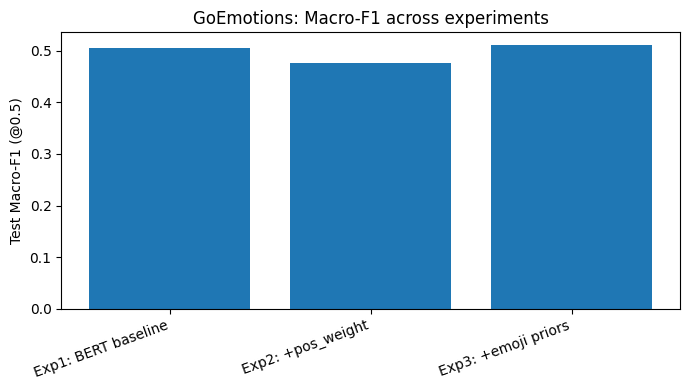

Saved: thesis_main_results.csv, macro_f1_bar.png


In [20]:
import pandas as pd
import matplotlib.pyplot as plt

# ====== Fill these with your final TEST numbers (@0.5) ======
RESULTS = [
    {"experiment": "Exp1: BERT baseline",       "macro_f1": 0.5057, "micro_f1": 0.5877, "note": "strong baseline"},
    {"experiment": "Exp2: +pos_weight",         "macro_f1": 0.4772, "micro_f1": 0.5252, "note": "hurts overall F1"},
    {"experiment": "Exp3: +emoji priors",       "macro_f1": 0.5103, "micro_f1": 0.5837, "note": "small macro gain"},
]

results_df = pd.DataFrame(RESULTS)

# Save for thesis appendix / reproducibility
results_df.to_csv("thesis_main_results.csv", index=False)

# Pretty print
display(results_df)

# ====== Minimal plot: Macro-F1 only ======
plt.figure(figsize=(7, 4))
plt.bar(results_df["experiment"], results_df["macro_f1"])
plt.ylabel("Test Macro-F1 (@0.5)")
plt.title("GoEmotions: Macro-F1 across experiments")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.savefig("macro_f1_bar.png", dpi=300)
plt.show()

print("Saved: thesis_main_results.csv, macro_f1_bar.png")
